# 15.777 Homework 1 (Spring 2024): Convolutional Neural Networks


In [32]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

<font color='red'> **Please be sure to make a copy of this notebook in your own Google Drive so that your work is saved!** </font>

# Introduction

Your goal in this exercise is to detect emotion from a facial image. To that end, we will use the 2013 Facial Expression Recognition (FER) dataset.

The dataset consists of ~36,000 images, each annotated with one of seven labels:
* angry
* disgust
* fear
* happy
* sad
* surprise
* neutral

The goal of this homework assignment is to walk you through how to:

1. Build a Convolutional Neural Network (CNN) *from scratch* to detect emotion in facial images (Problems 1 and 2)
2. Use data augmentation to increase the size of your training data (Problem 3)
3. Use transfer learning to customize a pretrained model to solve the same problem (Problem 4)

But first, let's get the data.

In [33]:
!wget -q -O fer2013.csv -P ./ https://dl.dropbox.com/scl/fi/e2ik6aryemboameq1rwwn/fer2013.csv?rlkey=ux7tyge6flk9nnuul9desizgf&dl=0

The data has 35887 rows and 3 columns:
* Emotion - encoded as the numbers 0 (anger) through 6 (neutral)
* Pixels - A space-separated list of numbers representing the pixels of this image.
* Usage - No need to worry about this column

In [34]:
data = pd.read_csv('fer2013.csv')
data

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training
...,...,...,...
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest


The pixel values for each image is provided as a space-separated list of numbers. How many pixels in an image?

In [4]:
len(data.loc[0, 'pixels'].split(' '))

2304

### Pre-Processing the Pixels (Independent Variable)

Each image is encoded as a list of 2304 pixels. We will reshape this into an 48x48 image next.

Recall that a color image is represented as a tensor of dimension N by M by 3, where the 3 represents the 3 color channels (red, green and blue). Our images from the FER 2013 dataset are grayscale images, with only a single channel representing the amount of black in the image. This is inconvenient to work with because many pre-trained models used in transfer learning, such as the one we will use in Problem 4, require the input image to have 3 channels.

To get around this, we will take each image, a 48 x 48 tensor and transform it into a 48 x 48 x 3 tensor by simply duplicating it three times. We can think of a greyscale image is one where the red, green and blue color channels are exactly the same.

The following code transforms our dataset into a tensor of shape (35887, 48, 48, 3): a list of 35887 images, each of which are a (48, 48, 3)-shape tensor.

In [35]:
pixels = data['pixels'].tolist()
width, height = 48, 48
faces = []
for pixel_sequence in pixels:
    face = [int(pixel) for pixel in pixel_sequence.split(' ')] # read each face as a 1-d array
    face = np.asarray(face).reshape(width, height) # reshape the length 2304 1-d array into an 48x48 array
    face = np.stack((face,)*3, axis=-1)
    faces.append(face.astype('float32'))

faces = np.asarray(faces)
faces.shape

(35887, 48, 48, 3)

For the first image, i.e. `faces[0]`, we can examine its first channel (corresponding to "red").

In [36]:
faces[0, :, :, 0]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

This is the exact same as the second channel (corresponding to "blue"). And similarly for green.

In [37]:
faces[0, :, :, 1]

array([[ 70.,  80.,  82., ...,  52.,  43.,  41.],
       [ 65.,  61.,  58., ...,  56.,  52.,  44.],
       [ 50.,  43.,  54., ...,  49.,  56.,  47.],
       ...,
       [ 91.,  65.,  42., ...,  72.,  56.,  43.],
       [ 77.,  82.,  79., ..., 105.,  70.,  46.],
       [ 77.,  72.,  84., ..., 106., 109.,  82.]], dtype=float32)

### Pre-Processing for Emotions (Dependent Variable)

Next, let's take a look at how emotion (the dependent variable) is encoded. We have that 0 = 'angry', 1 = 'disgust', ... 6 = 'neutral'.

In [38]:
data.emotion.unique()

array([0, 2, 4, 6, 3, 5, 1])

We will convert emotion to a one-hot encoding using the `pd.get_dummies` function.

In [39]:
emotions = pd.get_dummies(data['emotion']).to_numpy() # each emotion is 'one-hot' encoded as a 7-dim vector
emotions_names = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
emotions.shape

(35887, 7)

### Example Images
Lets take a look at some of these fun images!

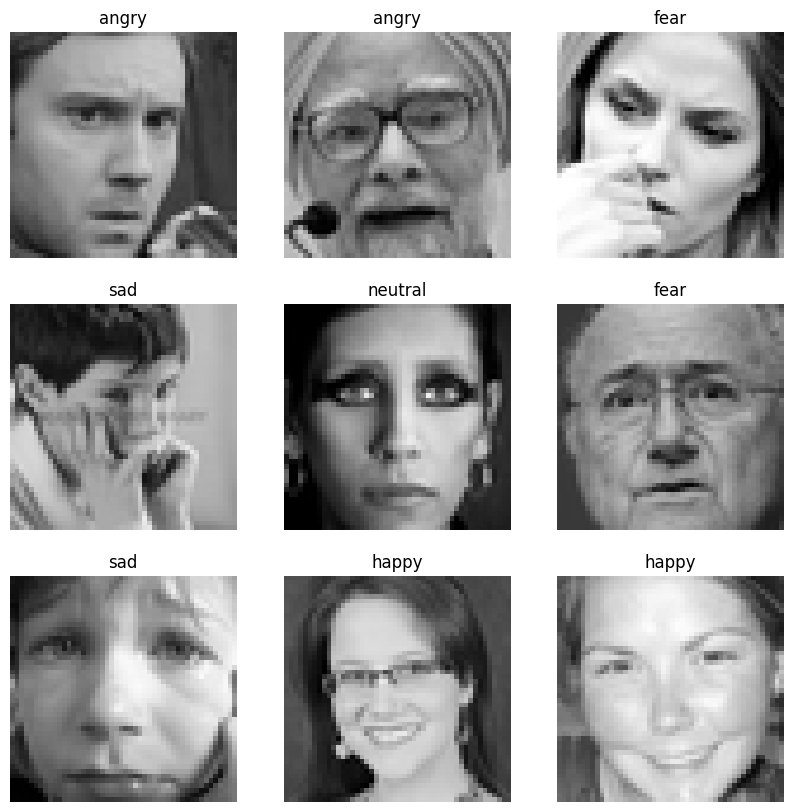

In [40]:
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.set_title(f"{emotions_names[np.argmax(emotions[i])]}")
    ax.imshow(faces[i].astype('uint8'))
    ax.axis('off')

### Train/Test Split
As in the original dataset, we will reserve the first 28,709 images for training and the rest for testing.

In [41]:
train_faces, train_emotions =  faces[:28709], emotions[:28709]
test_faces, test_emotions =  faces[28709:], emotions[28709:]

train_faces.shape, train_emotions.shape, test_faces.shape, test_emotions.shape

((28709, 48, 48, 3), (28709, 7), (7178, 48, 48, 3), (7178, 7))

# Problem 1: Base Model [30 Points]
In this problem, we will build a simple CNN with three convolutional blocks, one dense layer and one output layer.



## Part (a): Building the Model [10 points]
We would like to build a CNN with the following model summary. Fill in the code in the cell below so that the output of `model.summary()` matches that of the image above. Be sure to use relu activation for each of the Conv2D layers and the appropriate activation function for the output layer.


![](https://dl.dropbox.com/scl/fi/lrmaupoa243xrrsfj3qiy/cnn_model.PNG?rlkey=n5axqin6vx652qrgduyosg0pc&dl=0)

In [42]:
input = keras.Input(shape=(48, 48, 3), name="input")

x = keras.layers.Rescaling(scale=1./255)(input)

# Hidden Layer 1
x = keras.layers.Conv2D(16,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_1')(x)
x = keras.layers.MaxPool2D()(x)
# Hidden Layer 2
x = keras.layers.Conv2D(16,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_2')(x)
x = keras.layers.MaxPool2D()(x)
# Hidden layer 3
x = keras.layers.Conv2D(16,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_3')(x)
x = keras.layers.MaxPool2D()(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
output = keras.layers.Dense(7, activation='softmax')(x)

model = keras.Model(input, output, name='CNN_model')
model.summary()

Model: "CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 16)     │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       102,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,743 (416.96 KB)

 Trainable params: 106,743 (416.96 KB)

 Non-trainable params: 0 (0.00 B)

## Part (b): Number of Parameters [10 points]
The model above has $106,743$ trainable parameters and is computed by $208 + 1040 + 1040 + 102656 + 1799$. Explain how each of these 5 numbers is calculated and show your computations (e.g. 208 = 16 * 3 * 4 + 16).


Answer: Here,

kernel_size = 2 * 2

input_channels = 3

first hidden layer=16 with each having 1 bias

Therefore, 2* 2 * 3 * 16 + 16 = 208

Next for Conv_1, 2 * 2 * 16 * 16 + 16 = 1040

Output_shape = 48 * 48 * 3 --> 47 * 47 * 16

Maxpool does not have any parameters

Output_shape = 47 * 47 * 16 --> 23 * 23 * 16

For Conv_2, 2 * 2 * 16 * 16 + 16 = 1040

Output_shape = 23 * 23 * 16 --> 22 * 22 * 16

Maxpool does not have any parameters

Output_shape = 22 * 22 * 16 --> 11 * 11 * 6

Conv3,

Output_shape = 11 * 11 * 16 --> 10 * 10 * 16

Maxpool,

Output_shape = 10 * 10 * 16 --> 5 * 5 * 16

Flatten does not have any parameters

For Dense, Input layers are 400 from flatten. So, 400 * 256 + 256 = 102656

For Output layer, 256 * 7 + 7 = 1799

So, Total param = 106743





## Part (c): Training and Evaluation [10 points]

Let us compile our model and fit it on the training data. Since we one-hot-encoded the dependent variable, we use `categorical_crossentropy`, not `sparse_categorical_crossentropy`.

Fill in the parameters of `model.compile` and `model.fit` below.

* Compile the model using the `categorical_crossentropy` loss, `adam` optimizer and report the `accuracy` metric.
* Fit the model on `train_faces`, `train_emotions` using a batch size of 64, for 30 epochs and a validation split of 20%.

In [43]:
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

model_history = model.fit(train_faces, train_emotions, batch_size=64,epochs=30,validation_split=0.2)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.2974 - loss: 1.7367 - val_accuracy: 0.3673 - val_loss: 1.6482
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3884 - loss: 1.5759 - val_accuracy: 0.4209 - val_loss: 1.5376
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4285 - loss: 1.4868 - val_accuracy: 0.4455 - val_loss: 1.4651
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4521 - loss: 1.4210 - val_accuracy: 0.4622 - val_loss: 1.4203
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4741 - loss: 1.3680 - val_accuracy: 0.4758 - val_loss: 1.3828
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4967 - loss: 1.3198 - val_accuracy: 0.4854 - val_loss: 1.3542
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5155 - loss: 1.2756 - val_accuracy: 0.4944 - val_loss: 1.3323
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5344 - loss: 1.2310 - val_accuracy: 0

**Epochs and Batches.**

In your own words, please explain the relationship between an epoch and a batch in stochastic gradient descent.

Batches is the small mini sets of data in which dataset is divided. In this cases it is of shape 359.

Epoch is the 1 iteration/sweep of full dataset to tune the params.




When we ran `model.fit`, we saw that there are 359 batches per epoch. Please explain how this 359 is calculated. _Hint_: There are 28,709 training data points and 20% is set aside for validation.

We have decided batch_size to be 64. When we seperate the 20% for validation and divide the remaining number by 64 we get 359.


**Plotting the Training/Validation Accuracy Curve**

Use the `plot_accuracy` function below to plot the training and validation accuracy across the training epochs.

In [44]:
def plot_accuracy(model_history):
    history_dict = model_history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training Accuracy", linewidth=3)
    plt.plot(epochs, val_acc, "b", label="Validation Accuracy", linewidth=3)
    plt.title("Training and Validation Accuracy Across Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()



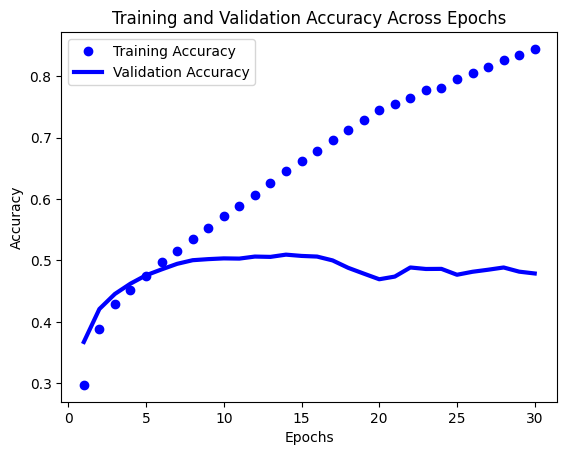

In [45]:
plot_accuracy(model_history)

**Model Accuracy**

Calculate the accuracy on the test set. Write your code below to show the accuracy.

In [46]:
model.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4738 - loss: 2.4681


[2.468073606491089, 0.4738088548183441]

# Problem 2: Wider and Deeper Models [30 Points]
In this problem, we will modify the model from Problem 1 in two ways:
* Increase the width of the model by adding more filters and more neurons in the dense layer.
* Increase the depth of the model by adding another dense layer.

### Part (a): Wider Model [5 points]
Take the `model` from Problem 1 and modify it into `wider_model` by using 32 filters for the convolution layers instead of 16.


Write your new code below and verify that `wider_model.summary()` looks correct. Your model should have 215,527 parameters.



In [ ]:
input = keras.Input(shape=train_faces.shape[1:])

h = keras.layers.Rescaling(scale=1./255)(input)

# Hidden Layer 1
h = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_1')(h)
h = keras.layers.MaxPool2D()(h)

# Hidden Layer 2
h = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_2')(h)
h = keras.layers.MaxPool2D()(h)
# Hidden layer 3
h = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_3')(h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu')(h)
output = keras.layers.Dense(7, activation='softmax')(h)

wider_model = keras.Model(input, output, name='wider_cnn')
wider_model.summary()

## Part (b): Number of Parameters [5 points]
The model above has $215,527$ trainable parameters and is computed by $416 + 4128 + 4128 + 205056 + 1799$. Explain how each of these 5 numbers is calculated and show your computations.

input to to conv1: Parameters are 2x2x3x32+32=416, shape is 48x48x3

conv1 to maxpool1: Parameters are zero, shape is 48x48x3 --> 47x47x32

maxpool to conv2: Parameters are 32x32x2x2+32=4128, shape is 47x47x32 --> 23x23x32

Conv2 to maxpool2: Parameters are zero, shape is 23x23x32 --> 22x22x32

maxpool2 to conv3: Parameters are 32x32x2x2+32=4128, shape is 22x22x32 --> 11x11x32

Conv3 to maxpool3: Parameters are zero, shape is 11x11x32 --> 10x10x32

maxpool3 to maxpool4: Parameters are zero, shape is 10x10x32 --> 5x5x32

flatten to dense: Parameters are 5x5x32x256+256=205056

Dense to output: Parameters are 256x7+7=1799


## Part (c): Training and Evaluation [5 points]
Let's train our model and evaluate its performance.

In [ ]:
wider_model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
# model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

# model_history = model.fit(train_faces, train_emotions, batch_size=64,epochs=30,validation_split=0.2)
wider_model_history = wider_model.fit(train_faces, train_emotions, batch_size=64,epochs=30,validation_split=0.2)

In [ ]:
plot_accuracy(wider_model_history)

In [ ]:
model.evaluate(test_faces, test_emotions)

Compare the accuracy curve of `wider_model` to that of `model` from Problem 1. Which shows more evidence of overfitting after 30 epochs? Does that make sense?

Wider model shows more evicennce of overfitting as the training accuracy reaches 100% more faster than the initial model. This makes sense because wider model has more parameters and thus the optimizer and thus the optimizer has more flexibility in reducing the training loss.



## Part (d): Deeper Model [5 Points]
Now, build a new model called `deep_model` by taking `model` from Problem 1 and add an additional dense layer of 256 nodes immediately after the original dense layer of 256 nodes. The new model should have a total of 2 dense layers of 256 nodes each and have a total of 172,535 parameters.

Train the model, plot its accuracy vs epochs using the `plot_accuracy` function, and report the model's accuracy on the test set.

In [ ]:
input = keras.Input(shape=train_faces.shape[1:])

h = keras.layers.Rescaling(scale=1./255)(input)

# Hidden Layer 1
h = keras.layers.Conv2D(16,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_1')(h)
h = keras.layers.MaxPool2D()(h)
# Hidden Layer 2
h = keras.layers.Conv2D(16,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_2')(h)

h = keras.layers.MaxPool2D()(h)
# Hidden layer 3
h = keras.layers.Conv2D(16,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_3')(h)

h = keras.layers.MaxPool2D()(h)
h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu')(h)
h = keras.layers.Dense(256, activation='relu')(h)
output = keras.layers.Dense(7, activation='softmax')(h)

deeper_model = keras.Model(input, output, name='deeper_cnn')
deeper_model.summary()

In [ ]:
deeper_model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
# model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

# model_history = model.fit(train_faces, train_emotions, batch_size=64,epochs=30,validation_split=0.2)
deeper_model_history = deeper_model.fit(train_faces, train_emotions, batch_size=64,epochs=30,validation_split=0.2)

In [ ]:
plot_accuracy(deeper_model_history)

In [ ]:
# Calculate the test accuracy
### YOUR CODE HERE ###
deeper_model.evaluate(test_faces, test_emotions)

## Part (e): Comparison [10 points]
Comment on the difference between the test accuracy of `model`, `wider_model` and `deeper_model`. Did widening the model or deepening the model result in a better performance? Why? Do you think
this result generally holds true for all problems?

<font color='red'>**Your Answer**</font>

Test Accuracy Comparison:
* `model`: 48.00%
* `wider_model`: 48.00%
* `deeper_model`: 46.00%

Here, `wider_model` performed better as there seems to be a bottleneck in number of layers rather than extra dense layer. For this particular problem adding extra dense layer does not solve the existing issue and does not improve accuracy.

# Problem 3: Data Augmentation [15 Points]

The basic idea of augmentation is to alter the image so slightly that the value of the dependent variable (i.e. the category that it belongs to) doesn't change.

Keras allows us to easily perform data augmentation using layers such as:

* `keras.layers.RandomFlip`
* `keras.layers.RandomZoom`
* `keras.layers.RandomRotation`

Lets quickly visualize what the augmentation does ... Here, we flip the images horizontally, then apply a random zoom of up to 20%. Note that you do not need to understand how the code below works. Most of it is there to allow us to visualize the augmentation.

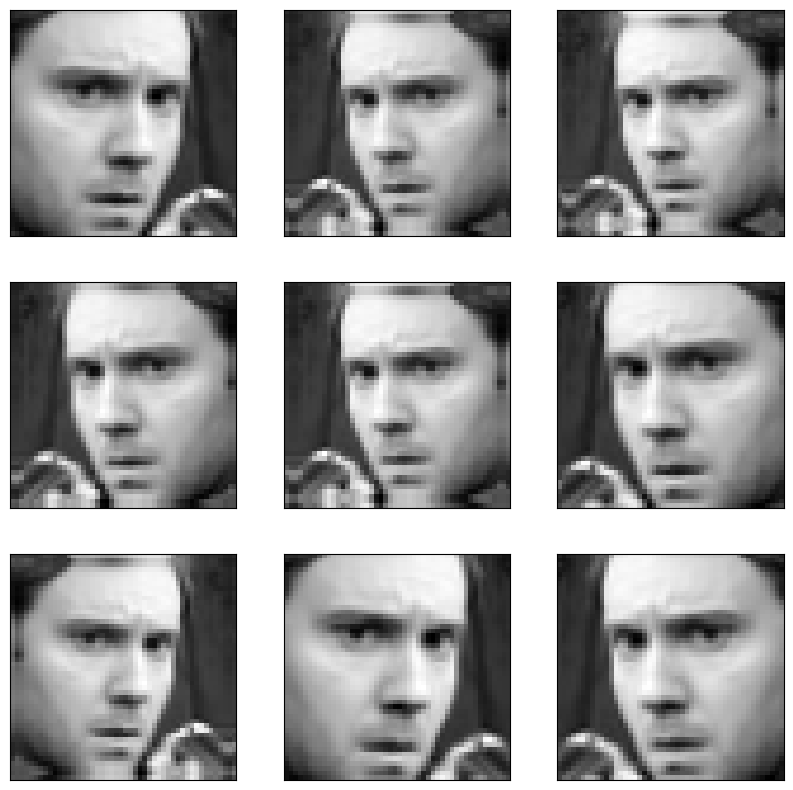

In [15]:
def augment_images(image):
    x = keras.layers.RandomFlip("horizontal")(image)
    x = keras.layers.RandomZoom(0.2)(x)
    return x

augmented_images = [augment_images(np.expand_dims(train_faces[0],axis=0)) for i in range(9)]
fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1, xticks=[], yticks=[])
    ax.imshow(tf.keras.preprocessing.image.array_to_img(augmented_images[i][0]), cmap='gray', vmin=0, vmax=255)

We take our model `wider_model` from Problem 2(c) and add a random flip and random zoom as **layers** before the rescaling layer.

In [16]:
input = keras.Input(shape=(48, 48, 3))

### DATA AUGMENTATION ###
x = keras.layers.RandomFlip("horizontal")(input)
x = keras.layers.RandomZoom(0.2)(x)

### YOUR CODE HERE ###
# input = keras.Input(shape=train_faces.shape[1:])

h = keras.layers.Rescaling(scale=1./255)(x)

# Hidden Layer 1
h = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_1')(h)
h = keras.layers.MaxPool2D()(h)

# Hidden Layer 2
h = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_2')(h)
h = keras.layers.MaxPool2D()(h)
# Hidden layer 3
h = keras.layers.Conv2D(32,
                        kernel_size=(2,2),
                        activation='relu',
                        name='Conv_3')(h)
h = keras.layers.MaxPool2D()(h)
h = keras.layers.Flatten()(h)
h = keras.layers.Dense(256, activation='relu')(h)
output = keras.layers.Dense(7, activation='softmax')(h)

# wider_model = keras.Model(input, output, name='wider_cnn')

model_augmented = keras.Model(input, output, name='augmented_CNN_model')
model_augmented.summary()

Model: "augmented_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_10 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_10 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 47, 47, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 22, 22, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,527 (841.90 KB)

 Trainable params: 215,527 (841.90 KB)

 Non-trainable params: 0 (0.00 B)

Train the model (using the same parameters as all previous questions), show the accuracy vs. epoch curve, and report the accuracy on the test set.

In [17]:
model_augmented.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy']
    ### YOUR CODE HERE ###
)

model_augmented_history = model_augmented.fit(train_faces, train_emotions, batch_size=64,epochs=30,validation_split=0.2
    ### YOUR CODE HERE ###
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2952 - loss: 1.7342 - val_accuracy: 0.3784 - val_loss: 1.6088
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3907 - loss: 1.5676 - val_accuracy: 0.4336 - val_loss: 1.4679
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4307 - loss: 1.4776 - val_accuracy: 0.4747 - val_loss: 1.3800
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4577 - loss: 1.4132 - val_accuracy: 0.4829 - val_loss: 1.3506
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4751 - loss: 1.3692 - val_accuracy: 0.5033 - val_loss: 1.3038
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4898 - loss: 1.3296 - val_accuracy: 0.5206 - val_loss: 1.2632
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4958 - loss: 1.3034 - val_accuracy: 0.5244 - val_loss: 1.2551
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5125 - loss: 1.2768 - val_accuracy:

In [ ]:
plot_accuracy(model_augmented_history)

In [18]:
# Calculate the test accuracy
### YOUR CODE HERE ###
model_augmented.evaluate(test_faces, test_emotions)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5430 - loss: 1.2544


[1.2544260025024414, 0.5430482029914856]

Compare this with `wider_model` and comment on the impact of data augmentation.

* Did data augmentation reduce overfitting?
* Did data augmentation improve test set accuracy


Here, there is significant jump in test set accuracy from 48% to 54%. It seems that augmentation has significantly reduced the overfitting as the validation accuracy curve is increasing for longer time period and training accuracy curve no longer hits 100% so quickly.

# Problem 4: Transfer Learning and Fine-Tuning [25 points]

Next, we apply transfer learning to our problem using VGG19, a pre-trained model similar to ResNet50 from class. We will take VGG19 and make it "headless", then run it through our own "little" NN.

We will take three different approaches to this:

1. Part (a): **Base Transfer Learning**. Fix the weights from headless VGG19 and learn the weights on the little NN.
2. Part (b): **Some fine-tuning** Fix the weights on the top 6 out of 19 layers of VGG19, but allow the weights from the remaining 13 layers to be optimized by SGD/Adam, in addition to those of the little NN.
3. Part (c): **Fine-Tuning** Allow all weights in VGG19 to be tuned, in addition to the little NN.

For each of the models, we will plot their train/validation accuracy curve, compute their test accuracy, and compute a confusion matrix.

## Part (a): No Fine Tuning [5 Points]

Let us fetch the VGG19 model, making sure to set `include_top=False` so that we do not take its output layer. We also set `trainable=False` to indicate that the parameters in these 19 layers are not trainable.



In [19]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=(48, 48, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

# Freeze the base_model so that it is not trainable at all
base_model.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


We build a neural network that performs data augmentation and rescaling, then uses the VGG19, and finally has one dense layer before the output layer.

In [23]:
inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model one at a time
x = base_model(x, training=False)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='transfer_model')
transfer_model.summary()

Model: "transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_14 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_14 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Train the model. Here, we use a learning rate of 0.00002 to get better convergence.

In [24]:
transfer_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

transfer_model_history = transfer_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.2372 - loss: 1.8466 - val_accuracy: 0.2837 - val_loss: 1.7517
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2985 - loss: 1.7354 - val_accuracy: 0.3229 - val_loss: 1.6949
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3212 - loss: 1.7001 - val_accuracy: 0.3339 - val_loss: 1.6693
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3300 - loss: 1.6819 - val_accuracy: 0.3417 - val_loss: 1.6540
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3327 - loss: 1.6702 - val_accuracy: 0.3462 - val_loss: 1.6430
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3386 - loss: 1.6630 - val_accuracy: 0.3511 - val_loss: 1.6353
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3418 - loss: 1.6550 - val_accuracy: 0.3548 - val_loss: 1.6283
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3451 - loss: 1.6492 - 

We can plot the training and validation accuracy curve.

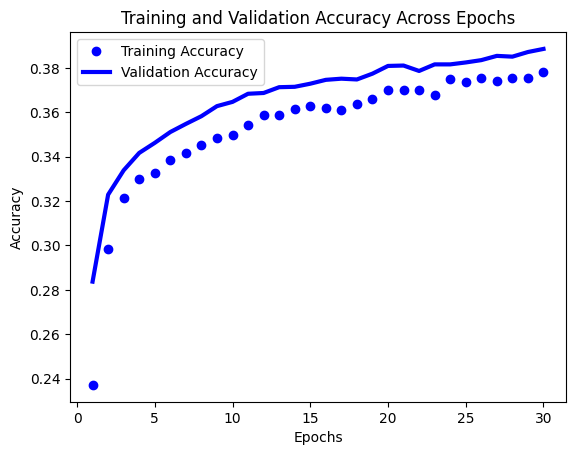

In [47]:
plot_accuracy(transfer_model_history)

Let's also calculate the confusion matrix and the accuracy on the test set.

The function `show_confusion_matrix` has been written for you below. You can apply it to any Keras Model and it will calculate:
* Test accuracy
* A confusion matrix. Recall that each row of the confusion matrix are the actual labels and each column are the predictions. For example, if element in row `happy` and column `sad` is 250, then there are 250 data points in the test set where the true label is `happy` but we predicted `sad`.
* A heatmap of the confusion matrix, where each row is normalized to add up to 1.0. For example, if element in row `happy` and column `sad` is 0.25, then that means 25% of data points with a true label of `happy` were predicted as `sad`.

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
*************************
* Test Accuracy: 0.3788 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,149,0,51,426,108,59,165
disgust,11,0,13,51,16,8,12
fear,67,0,134,378,144,143,158
happy,75,0,44,1308,109,49,189
sad,96,0,83,534,311,33,190
surprise,32,0,69,193,27,405,105
neutral,79,0,52,523,110,57,412


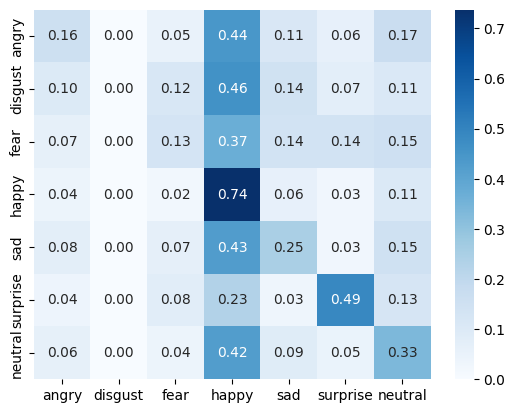

In [27]:
from IPython.display import display

def show_confusion_matrix(model):
    """
    Calculates the test accuracy, confusion matrix and heat map for a model.
    """
    global test_faces, test_emotions, emotions_names

    y_pred = model.predict(test_faces).argmax(axis=1)
    y_actual = test_emotions.argmax(axis=1)

    print('*************************\n* Test Accuracy: %.4f *\n*************************' % metrics.accuracy_score(y_actual, y_pred))

    cm = pd.DataFrame(metrics.confusion_matrix(y_actual, y_pred), index=emotions_names, columns=emotions_names)
    display(cm)

    cm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(cm, cmap="Blues", annot=True, fmt=".2f")

show_confusion_matrix(transfer_model)

Please comment briefly on the model's performance.

<font color='red'> **Your Answer** </font>

Here, we can see that the accuracy is more where there are more datapoints for particular output variable. This means the model is overfit.

## Part (b): Some Fine Tuning [5 Points]
In this part, we will allow our optimization model to tune **some** of the layers from VGG19. In particular, we will only freeze the first 15 layers and allow the remaining layers to be trained.


In [52]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model
# for layer in base_model.layers:
#     x = layer(x)
for layer in base_model.layers:
    if isinstance(layer, keras.layers.InputLayer):
        continue
    x = layer(x)

# x = base_model(x, training=False)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

partial_model = keras.Model(inputs, outputs, name='partial_fine_tune_model')

# Make the first 15 layers not trainable. All other layers are trainable
for layer in partial_model.layers[:15]:
    layer.trainable = False

partial_model.summary()

Model: "partial_fine_tune_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_20 (RandomFlip)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_20 (RandomZoom)     │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 17,831,943 (68.02 MB)

 Non-trainable params: 2,325,568 (8.87 MB)

Let's see which layers are trainable. Notice that VGG19 consists of 4 blocks of convolution filters (block1_conv1, block1_conv2, ..., block5_conv4). We are allowing block4 and block5 to be trained and freezing blocks 1, 2 and 3.

In [53]:
for i, layer in enumerate(partial_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_18 (InputLayer), Trainable=False
Layer 2: random_flip_20 (RandomFlip), Trainable=False
Layer 3: random_zoom_20 (RandomZoom), Trainable=False
Layer 4: rescaling_13 (Rescaling), Trainable=False
Layer 5: block1_conv1 (Conv2D), Trainable=False
Layer 6: block1_conv2 (Conv2D), Trainable=False
Layer 7: block1_pool (MaxPooling2D), Trainable=False
Layer 8: block2_conv1 (Conv2D), Trainable=False
Layer 9: block2_conv2 (Conv2D), Trainable=False
Layer 10: block2_pool (MaxPooling2D), Trainable=False
Layer 11: block3_conv1 (Conv2D), Trainable=False
Layer 12: block3_conv2 (Conv2D), Trainable=False
Layer 13: block3_conv3 (Conv2D), Trainable=False
Layer 14: block3_conv4 (Conv2D), Trainable=False
Layer 15: block3_pool (MaxPooling2D), Trainable=False
Layer 16: block4_conv1 (Conv2D), Trainable=True
Layer 17: block4_conv2 (Conv2D), Trainable=True
Layer 18: block4_conv3 (Conv2D), Trainable=True
Layer 19: block4_conv4 (Conv2D), Trainable=True
Layer 20: block4_pool (MaxPooling2D), Trainabl

Train the model and examine its train/validation curve, test accuracy and confusion matrix.

In [54]:
partial_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

partial_model_history = partial_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.4105 - loss: 1.5218 - val_accuracy: 0.4835 - val_loss: 1.3718
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.5042 - loss: 1.2985 - val_accuracy: 0.5197 - val_loss: 1.2783
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.5413 - loss: 1.2113 - val_accuracy: 0.5488 - val_loss: 1.1863
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.5699 - loss: 1.1354 - val_accuracy: 0.5627 - val_loss: 1.1646
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.5935 - loss: 1.0757 - val_accuracy: 0.5669 - val_loss: 1.1532
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6255 - loss: 1.0098 - val_accuracy: 0.5679 - val_loss: 1.1562
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6468 - loss: 0.9498 - val_accuracy: 0.5784 - val_loss: 1.1472
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.6710 - loss: 0.8927 - 

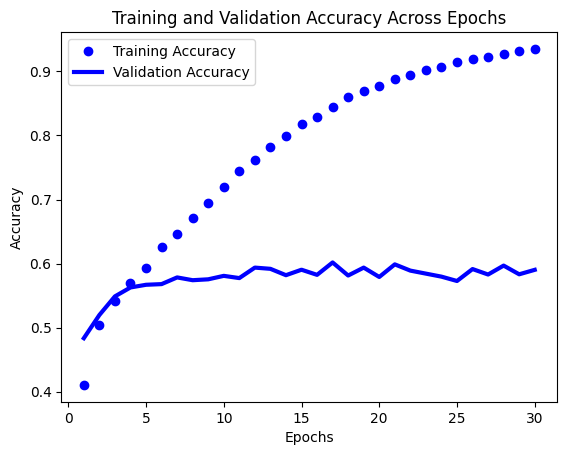

In [55]:
plot_accuracy(partial_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
*************************
* Test Accuracy: 0.5901 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,409,4,77,78,271,31,88
disgust,27,45,5,4,22,3,5
fear,89,1,395,63,316,95,65
happy,43,0,38,1490,84,34,85
sad,105,4,98,107,775,27,131
surprise,18,0,80,43,59,611,20
neutral,71,1,77,183,361,29,511


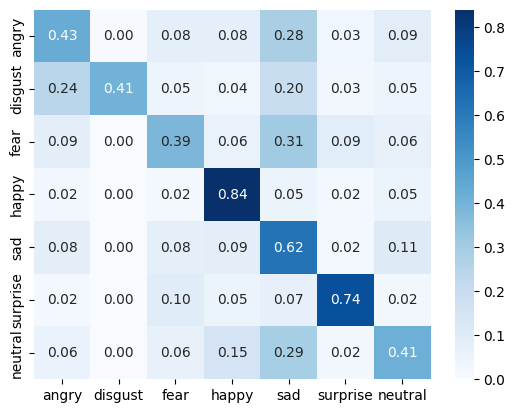

In [56]:
show_confusion_matrix(partial_model)

Please comment briefly on the model's performance.  

<font color='red'> **Your Answer** </font>

We get 59% accuracy which is significantly better than the last. Most of the classes are classified according to confusion matrix.

## Part (c): Fine Tuning [5 Points]
Now, let's try a transfer learning model where all layers can be fine tuned.

In [58]:
base_model = keras.applications.VGG19(
    include_top=False,   # this makes VGG19 headless
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
)

inputs = keras.Input(shape=(48,48,3))

x = keras.layers.RandomFlip("horizontal")(inputs)
x = keras.layers.RandomZoom(0.2)(x)
x = keras.layers.Rescaling(1./255)(x) # normalizing

# Add layers from base_model
# for layer in base_model.layers:
#     x = layer(x)

for layer in base_model.layers:
    if isinstance(layer, keras.layers.InputLayer):
        continue
    x = layer(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(7, activation='softmax')(x)

tuned_model = keras.Model(inputs, outputs, name='full_fine_tune_model')

# Let's see which layers are trainable
for i, layer in enumerate(tuned_model.layers):
    print('Layer %d: %s (%s), Trainable=%s' % (i+1, layer.name, layer.__class__.__name__, layer.trainable))

Layer 1: input_layer_22 (InputLayer), Trainable=True
Layer 2: random_flip_22 (RandomFlip), Trainable=True
Layer 3: random_zoom_22 (RandomZoom), Trainable=True
Layer 4: rescaling_15 (Rescaling), Trainable=True
Layer 5: block1_conv1 (Conv2D), Trainable=True
Layer 6: block1_conv2 (Conv2D), Trainable=True
Layer 7: block1_pool (MaxPooling2D), Trainable=True
Layer 8: block2_conv1 (Conv2D), Trainable=True
Layer 9: block2_conv2 (Conv2D), Trainable=True
Layer 10: block2_pool (MaxPooling2D), Trainable=True
Layer 11: block3_conv1 (Conv2D), Trainable=True
Layer 12: block3_conv2 (Conv2D), Trainable=True
Layer 13: block3_conv3 (Conv2D), Trainable=True
Layer 14: block3_conv4 (Conv2D), Trainable=True
Layer 15: block3_pool (MaxPooling2D), Trainable=True
Layer 16: block4_conv1 (Conv2D), Trainable=True
Layer 17: block4_conv2 (Conv2D), Trainable=True
Layer 18: block4_conv3 (Conv2D), Trainable=True
Layer 19: block4_conv4 (Conv2D), Trainable=True
Layer 20: block4_pool (MaxPooling2D), Trainable=True
Layer 21

In [59]:
tuned_model.compile(loss='categorical_crossentropy',
            optimizer=keras.optimizers.Adam(2e-5),
            metrics=['accuracy'])

tuned_model_history = tuned_model.fit(train_faces, train_emotions, epochs=30, validation_split=0.2)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.4415 - loss: 1.4405 - val_accuracy: 0.5313 - val_loss: 1.2502
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5395 - loss: 1.2127 - val_accuracy: 0.5435 - val_loss: 1.2142
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.5752 - loss: 1.1207 - val_accuracy: 0.5695 - val_loss: 1.1390
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6014 - loss: 1.0566 - val_accuracy: 0.5723 - val_loss: 1.1561
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6272 - loss: 0.9958 - val_accuracy: 0.5960 - val_loss: 1.0791
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6482 - loss: 0.9448 - val_accuracy: 0.5979 - val_loss: 1.0943
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.6725 - loss: 0.8888 - val_accuracy: 0.6048 - val_loss: 1.0644
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6898 - loss: 0.8361 - 

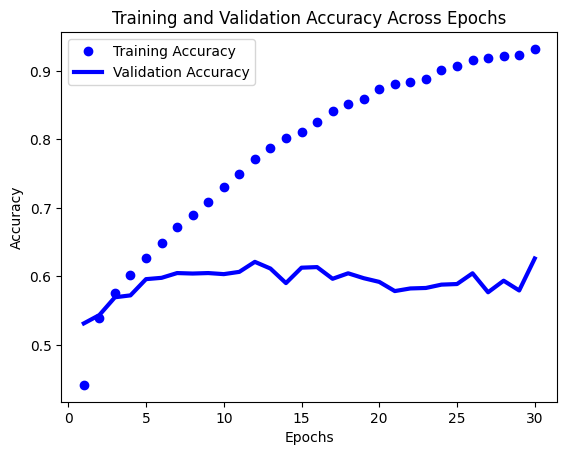

In [60]:
plot_accuracy(tuned_model_history)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
*************************
* Test Accuracy: 0.6120 *
*************************


,angry,disgust,fear,happy,sad,surprise,neutral
angry,566,3,78,42,157,20,92
disgust,46,38,7,2,8,5,5
fear,153,1,382,28,265,97,98
happy,47,1,46,1419,106,42,113
sad,171,2,111,57,716,25,165
surprise,27,2,76,43,23,638,22
neutral,95,1,56,103,306,38,634


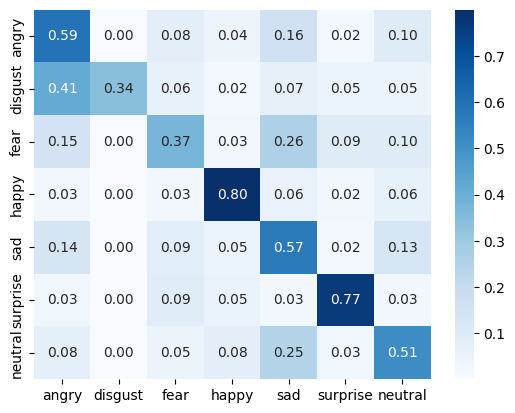

In [61]:
show_confusion_matrix(tuned_model)

Please comment briefly on the model's performance.  

<font color='red'> **Your Answer** </font>

2% increase in test accuracy.

## Part (d): Comparison [10 Points]

Please fill in the table below with the test accuracies of the three models above, as well as that of `wider_model` from Problem 2.

<font color='red'>**Your Answer.**</font>

Model Test Accuracy:
* Model (a) with no fine tuning: 37.00%
* Model (b) with some fine tuning: 59.00%
* Model (c) with fine tuning: 61.00%
* `wider_model` from Problem 2(a)-(c): 48.00%


Comment on the performance of Models (a), (b) and (c). In particular, please address the following questions:

* Why do models (b) and (c) perform so much better than `wider_model`?
* Why do you think Model (a) performs so poorly?
* Why do you think Model (c) performs better than model (b)?

<font color='red'>**Your Answer.**</font>


*   Model B and C highlight the value of transfer learnign. They utilize the
pre-trained representation from vgg19, a model architecture trained on millions of images from ImageNet. Wider_model was only trained on 20k images from training data making it less powerfull. By using pretrained weights, model B and C do not need to reinvent the wheel as some patterns and shapes used for detecting everyday objects can be translated to detecting emotions.
*   The reason why Model A perform bad because vgg19 is trained on general objects rather than facial expression. It is not able to extract such features.
*   Model c is more versatile model with more parameters to tunebecause more parts from vgg19 can be trained. THis additional flexibility increases performance but it tends to overfit the model as well.

